## Carga del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ecobici_df = pd.read_csv("./dataset/badata_ecobici_recorridos_realizados_2024.zip")

## Análisis exploratorio de los datos

In [3]:
ecobici_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


In [4]:
ecobici_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3559284 entries, 0 to 3559283
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id_recorrido                int64  
 1   duracion_recorrido          int64  
 2   fecha_origen_recorrido      str    
 3   id_estacion_origen          int64  
 4   nombre_estacion_origen      str    
 5   direccion_estacion_origen   str    
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     str    
 9   id_estacion_destino         int64  
 10  nombre_estacion_destino     str    
 11  direccion_estacion_destino  str    
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  float64
 15  modelo_bicicleta            str    
 16  genero                      str    
dtypes: float64(5), int64(4), str(8)
memory usage: 461.6 MB


### Características principales

- El set de datos posee 3559284 entradas
- Variables y tipos de datos:

| Nombre | Descripción | Tipo |
|-|-|-|
|id_recorrido                   | Número identificador de recorrido                    | Categórica nominal     |
| duracion_recorrido            | Duración del recorrido                               | Numérica               |
| fecha_origen_recorrido        | Fecha en que inició el recorrido                     | Categórica / Numérica  |
| id_estacion_origen            | Número identificador de estación de origen           | Categórica nominal     |
| nombre_estacion_origen        | Nombre de estación de origen                         | Categórica nominal     |
| direccion_estacion_origen     | Dirección de estación de origen                      | Categórica nominal     |
| long_estacion_origen          | Longitud de estación de origen                       | Numérica               |
| lat_estacion_origen           | Latitud de estación de origen                        | Numérica               |
| fecha_destino_recorrido       | Fecha en que finalizó el recorrido                   | Categórica / Numérica  |
| id_estacion_destino           | Número identificador de estación de destino          | Categórica nominal     |
| nombre_estacion_destino       | Nombre de estación de destino                        | Categórica nominal     |
| direccion_estacion_destino    | Dirección de estación de destino                     | Categórica nominal     |
| long_estacion_destino         | Longitud (coordenada) de estación de destino         | Numérica               |
| lat_estacion_destino          | Latitud (coordenada) de estación de destino          | Numérica               |
| id_usuario                    | Número identificador de usuario                      | Categórica nominal     |
| modelo_bicicleta              | Nombre del modelo de la bicicleta usada en recorrido | Categórica nominal     |
| genero                        | Género del usuario del recorrido                     | Categórica binaria     |

### Ajuste de variables

In [5]:
df_ecobici_numericas = ['duracion_recorrido', 'long_estacion_origen', 'lat_estacion_origen', 'long_estacion_destino', 'lat_estacion_destino']
df_ecobici_categoricas = ['id_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']

# Mapping para numericas y para categoricas
dtype_map = {col: 'float64'  for col in df_ecobici_numericas}
dtype_map.update({col: 'category' for col in df_ecobici_categoricas}) 

# Se aplica el mapping al dataframe
ecobici_df = ecobici_df.astype(dtype_map)

ecobici_df.dtypes

id_recorrido                  category
duracion_recorrido             float64
fecha_origen_recorrido        category
id_estacion_origen            category
nombre_estacion_origen        category
direccion_estacion_origen     category
long_estacion_origen           float64
lat_estacion_origen            float64
fecha_destino_recorrido       category
id_estacion_destino           category
nombre_estacion_destino       category
direccion_estacion_destino    category
long_estacion_destino          float64
lat_estacion_destino           float64
id_usuario                    category
modelo_bicicleta              category
genero                        category
dtype: object

### Estadística descriptiva

#### Variables numéricas

Se inicia el análisis a partir de la variable principal: __duracion_recorrido__, que indica cuanto dura cada recorrido

In [6]:
# Codigo tomado de clase_02_intro_EDA_Titanic
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [7]:
print("Duración de recorridos")

print(f"Media: {ecobici_df['duracion_recorrido'].mean()}")
print(f"Mediana: {ecobici_df['duracion_recorrido'].median()}")
print(f"Moda: {ecobici_df['duracion_recorrido'].mode()}")

duracion_recorrido_Q1, duracion_recorrido_Q2, duracion_recorrido_Q3 = cuartiles(ecobici_df['duracion_recorrido'])

print("Q1 (25%):", duracion_recorrido_Q1)
print("Q2 (Mediana, 50%):", duracion_recorrido_Q2)
print("Q3 (75%):", duracion_recorrido_Q3)

# Límites teóricos para detectar outliers
duracion_recorrido_IQR = duracion_recorrido_Q3 - duracion_recorrido_Q1
lower_limit = duracion_recorrido_Q1 - 1.5 * duracion_recorrido_IQR
upper_limit = duracion_recorrido_Q3 + 1.5 * duracion_recorrido_IQR

print(f"Rango intercuartil: {duracion_recorrido_IQR}")
print(f"Límite inferior para detectar outliers: {lower_limit}")
print(f"Límite superior para detectar outliers: {upper_limit}")

Duración de recorridos
Media: 1274.8267676869843
Mediana: 881.0
Moda: 0    2.0
Name: duracion_recorrido, dtype: float64
Q1 (25%): 493.0
Q2 (Mediana, 50%): 881.0
Q3 (75%): 1474.0
Rango intercuartil: 981.0
Límite inferior para detectar outliers: -978.5
Límite superior para detectar outliers: 2945.5


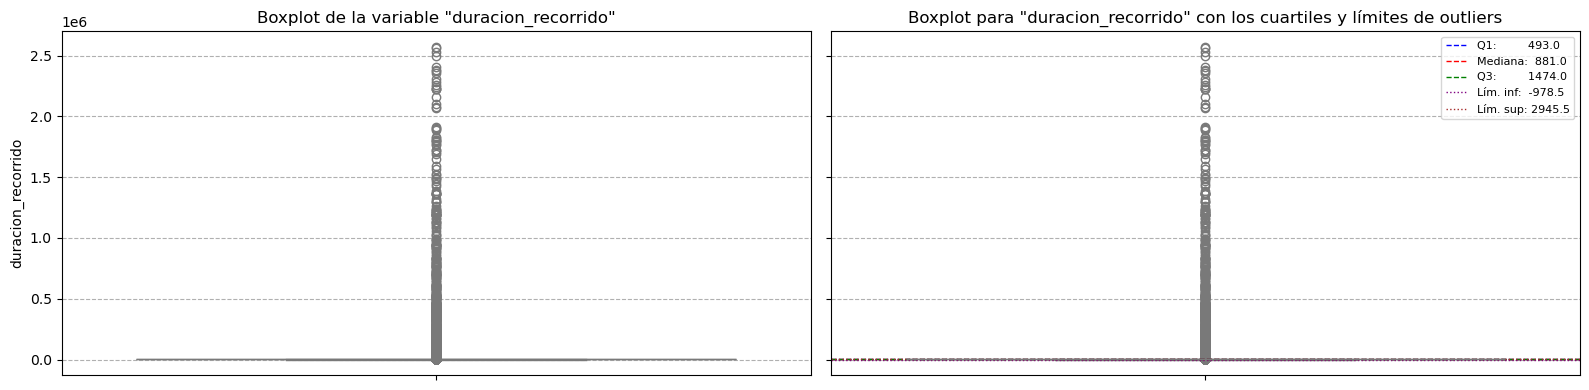

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

# ax[0]: Boxplot
sns.boxplot(data=ecobici_df, y='duracion_recorrido', color="lightblue", ax=ax[0])
ax[0].set_title('Boxplot de la variable "duracion_recorrido"')
ax[0].grid(axis='y', ls='--')

# ax[1]: Boxplot con detalles
sns.boxplot(data=ecobici_df, y='duracion_recorrido', color="lightblue", ax=ax[1])
ax[1].axhline(duracion_recorrido_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1:         {duracion_recorrido_Q1:.1f}')
ax[1].axhline(duracion_recorrido_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana:  {duracion_recorrido_Q2:.1f}')
ax[1].axhline(duracion_recorrido_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3:         {duracion_recorrido_Q3:.1f}')
ax[1].axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf:  {lower_limit:.1f}')
ax[1].axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')
ax[1].set_title('Boxplot para "duracion_recorrido" con los cuartiles y límites de outliers')
ax[1].legend(fontsize=8)
ax[1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

Los gráficos iniciales muestran que existen una cantidad muy grande de valores de duración de viaje en 0 segundos. Para chequear esto, se cuentan los viajes con esa duración

In [9]:
viajes_con_duracion_cero = (ecobici_df['duracion_recorrido'] == 0).sum()
viajes_totales = len(ecobici_df)
print(f"Cantidad de viajes totales: {viajes_totales}")
print(f"Cantidad de viajes con duración 0: {viajes_con_duracion_cero}")
print(f"Porcentaje de viajes con duración 0: {(viajes_con_duracion_cero * 100 / viajes_totales)} %")


Cantidad de viajes totales: 3559284
Cantidad de viajes con duración 0: 37618
Porcentaje de viajes con duración 0: 1.0568979603763005 %


In [10]:
ecobici_df.isna().sum()

id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino               0
nombre_estacion_destino           0
direccion_estacion_destino        0
long_estacion_destino             0
lat_estacion_destino              0
id_usuario                        0
modelo_bicicleta                  0
genero                        11946
dtype: int64

In [ ]:
print("Límite inferior para detectar outliers: ", limite_inferior_para_outliers, aclaracion_tiempo(limite_inferior_para_outliers))
print("Límite superior para detectar outliers: ", limite_superior_para_outliers, aclaracion_tiempo(limite_superior_para_outliers))